## Homework 8

### Pandas DataFrame

In [3]:
import pandas as pd

In [5]:
df = pd.read_csv("state_data.csv")

In [8]:
df.shape

(52, 4)

In [10]:
print(df.head())
print(df.tail())

  state   latitude   longitude        name
0    AK  63.588753 -154.493062      Alaska
1    AL  32.318231  -86.902298     Alabama
2    AR  35.201050  -91.831833    Arkansas
3    AZ  34.048928 -111.093731     Arizona
4    CA  36.778261 -119.417932  California
   state   latitude   longitude           name
47    VT  44.558803  -72.577841        Vermont
48    WA  47.751074 -120.740139     Washington
49    WI  43.784440  -88.787868      Wisconsin
50    WV  38.597626  -80.454903  West Virginia
51    WY  43.075968 -107.290284        Wyoming


The columns are the state abbreviation, latitude, longitude, and the state's full name.
The first state in the dataset is Alaska.
The last state in the dataset is Wyoming.
There are 52 entries total. This is greater than the amount of states (50) because this list includes Puerto Rico and DC.

In [14]:
median_lat = df["latitude"].median()
print('Median latitude = ', median_lat)
median_long = df["longitude"].median()
print('Median longitude = ', median_long)

Median latitude =  39.4355155
Median longitude =  -89.093198


In [15]:
df['dist_to_median_lat'] = (df['latitude'] - median_lat).abs()

In [27]:
df['dist_to_median_long'] = (df['longitude'] - median_long).abs()

In [18]:
df.shape

(52, 6)

In [22]:
closest_lat = df.loc[df['dist_to_median_lat'].idxmin()]

print(f"State: {closest_lat['state']}")
print(f"Distance to median latitude: {closest_lat['dist_to_median_lat']:.2f}")

State: CO
Distance to median latitude: 0.11


In [23]:
farthest_lat = df.loc[df['dist_to_median_lat'].idxmax()]

print(f"State: {farthest_lat['state']}")
print(f"Distance to median latitude: {farthest_lat['dist_to_median_lat']:.2f}")

State: AK
Distance to median latitude: 24.15


In [28]:
closest_long = df.loc[df['dist_to_median_long'].idxmin()]

print(f"State: {closest_long['state']}")
print(f"Distance to median latitude: {closest_long['dist_to_median_long']:.2f}")

State: IL
Distance to median latitude: 0.31


In [29]:
farthest_long = df.loc[df['dist_to_median_long'].idxmax()]

print(f"State: {farthest_long['state']}")
print(f"Distance to median latitude: {farthest_long['dist_to_median_long']:.2f}")

State: HI
Distance to median latitude: 66.57


In [30]:
df.describe()

,latitude,longitude,dist_to_median_lat,dist_to_median_long
count,52.000000,52.000000,52.000000,52.000000
mean,39.153437,-92.824719,4.815714,14.535330
std,6.967697,19.431647,4.998411,13.280351
min,18.220833,-155.665857,0.114536,0.305330
25%,35.438381,-102.009600,1.564952,6.037732
50%,39.435516,-89.093198,3.890968,11.903743
75%,43.220246,-78.291302,6.133912,17.832342
max,63.588753,-66.590149,24.153237,66.572659


I found this function at this link here: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html

This function gives descriptive statistics about the numerical values in the dataframe.

### Seaborn

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
flights = sns.load_dataset("flights")

In [35]:
flights = flights.dropna()

In [36]:
print(f"Shape: {flights.shape}") # There are 144 rows and 3 columns.

Shape: (144, 3)


In [37]:
print(flights.head())

   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121


In [38]:
print(flights.tail())

     year month  passengers
139  1960   Aug         606
140  1960   Sep         508
141  1960   Oct         461
142  1960   Nov         390
143  1960   Dec         432


The "year" column lists the year of the flight. The "month" column lists the month of the flight. The "passengers" column gives the number of passengers on that flight.

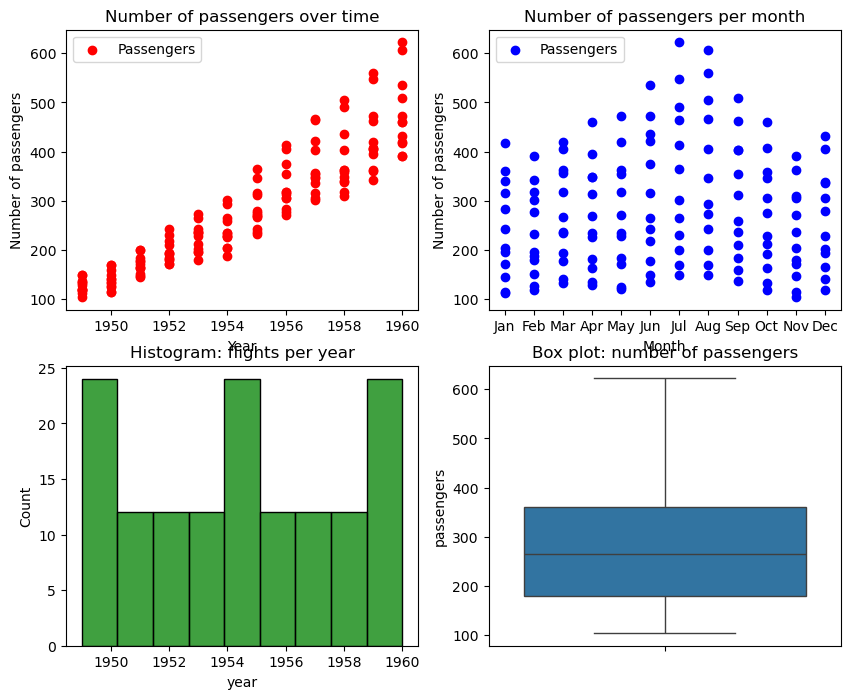

In [84]:
fig, ax = plt.subplots(2,2, figsize = (10,8))

ax[0, 0].scatter(flights["year"], flights["passengers"], c='r', label="Passengers")
ax[0, 0].set_xlabel("Year")
ax[0,0].set_ylabel("Number of passengers")
ax[0,0].set_title("Number of passengers over time")
ax[0,0].legend()


ax[0,1].scatter(flights["month"], flights["passengers"],c='b', label="Passengers")
ax[0,1].set_xlabel("Month")
ax[0,1].set_ylabel("Number of passengers")
ax[0,1].set_title("Number of passengers per month")
ax[0,1].legend()

sns.histplot(flights['year'], ax=ax[1,0],color='green')
ax[1,0].set_title('Histogram: flights per year')

sns.boxplot(flights['passengers'], ax=ax[1,1])
ax[1,1].set_title('Box plot: number of passengers')

plt.show()

**Upper left**: This shows the number of passengers on the flights in the data table per year. Per the plot, the number of passengers on flights has generally followed an upward trend.

**Upper right**: This shows the number of passengers on the recorded flights per month. Per the plot, the most passengers fly in the summer, as there is a peak in July.

**Lower left**: This shows the number of flights there are per year in this data table. The number of flights ranges from about 12 to 24 per year.

**Lower right**: This boxplot shows a statistical analysis of the number of passengers per flight. The average amount of passengers is approximately 275, but can be as low as 100 and, at the highest end, exceed 600.

### 4. Final Project Idea: Analyzing Data